# Deep Learning modeller
Her tænkes at afprøve hvorvidt deeplearning modeller kører for keyword spotting. Ved undersøgelse af modeller er der stødt på CNN, DS-CNN eller simpel MLP-NN modeller. Der bruges mfcc, mel og simple features som inputs og ikke rå lydfiler og sammenligner features, for at se hvilke fungerer bedst. Siden der 

Koden nedenfor er funktioner til at læse lydfiler, udregne mel, mfcc, frekvens og lignende, der bruges som features.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
FFT_N = 4096
N_MELS = 16
N_MFCC = 16
EPS = 1e-12

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak
    return x

def prepare_fft_frame(x: np.ndarray, fft_n: int = FFT_N) -> np.ndarray:
    frame = np.zeros(fft_n, dtype=np.float32)
    copy_len = min(len(x), fft_n)
    frame[:copy_len] = x[:copy_len]

    window = np.hanning(fft_n).astype(np.float32)
    frame *= window
    return frame

def magnitude_spectrum(x, fs, fft_n: int = FFT_N):
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, mag

def fft_real_only_power_emlearn_style(x, fs, fft_n: int = FFT_N):
    """
    Matcher eml_audio_power_spectrogram():
    bruger kun realdel af FFT-output og skalerer med 1/n_fft
    """
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(fft_n)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, power

def hz_to_mel(hz: float) -> float:
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels: float) -> float:
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n: int, n_mels: int, fmin: float, fmax: float) -> float:
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    mel = melmin + (n * melstep)
    return mel_to_hz(mel)

def eml_audio_mel_bin(hz: float, n_fft: int, samplerate: float) -> int:
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k: int, n_fft: int, samplerate: float) -> float:
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N):
    _, spec = fft_real_only_power_emlearn_style(x, fs, fft_n=fft_n)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + fft_n // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = eml_audio_mel_bin(left_hz, fft_n, fs)
        center = eml_audio_mel_bin(center_hz, fft_n, fs)
        right = eml_audio_mel_bin(right_hz, fft_n, fs)

        left = max(0, min(left, max_bin - 1))
        center = max(0, min(center, max_bin - 1))
        right = max(0, min(right, max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, fft_n, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += spec[k] * weight

        for k in range(center, right):
            if k + 1 >= len(spec):
                break
            r = right_hz - eml_fft_freq(k + 1, fft_n, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += spec[k + 1] * weight

        mels[m - 1] = val

    return mels

def dct_type_2(x: np.ndarray, n_out: int) -> np.ndarray:
    n = len(x)
    out = np.zeros(n_out, dtype=np.float32)
    for k in range(n_out):
        s = 0.0
        for m in range(n):
            s += x[m] * np.cos(np.pi * k * (m + 0.5) / n)
        out[k] = s
    return out

def mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N):
    mel = mel_spectrum_emlearn_style(x, fs, n_mels=n_mels, fft_n=fft_n)
    log_mel = np.log(mel + EPS)
    mfcc = dct_type_2(log_mel, n_mfcc)
    return mfcc.astype(np.float32)

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mel_vals = mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    mfcc_vals = mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES

train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)
# =========================


# =========================
# FEATURE SETS
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mel_feature_cols = [f"mel_{i}" for i in range(1, N_MELS + 1)]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "mel": mel_feature_cols,
    "Simplefeat_mfcc": mfcc_feature_cols + simple_features,
    "combined": simple_features + mfcc_feature_cols + mel_feature_cols,
}
# =========================



c:\ProgramData\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## MLP neural netværk
Siden vi har tabular mfcc bruges MLP neural netværk, og observere hvor vel den kan klassificere ordene. MLP structuren der er brugt her ser således ud:

input( input dimension (baseret på hvilken feature der brugt))

Dense(128) --> ReLU --> Dense(64) --> ReLU --> Dense(32) --> ReLU --> Dense(16) --> ReLU --> Dense(6, activation=sigmoid)

In [3]:
MODEL_EPOCHS = 1500
MODEL_PATIENCE = 100
BATCH_SIZE = 16

# =========================
# Choosing feature to train and test from
feat_name = "simple"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

 
 

input_dim = X_train.shape[1] 
# =========================

In [4]:
model_simpleFeatures = models.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_simpleFeatures.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,350 (13.09 KB)

 Trainable params: 3,350 (13.09 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_simpleFeatures.compile(
    optimizer=tf.keras.optimizers.SGD(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_simpleFeatures.fit(
    X_train_np, y_train_enc,
    validation_data=(X_test_np, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_simpleFeatures.predict(X_test_np)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================


    

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4217 - loss: 180.7655 - val_accuracy: 0.3929 - val_loss: 43.0845
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3983 - loss: 3.9029 - val_accuracy: 0.3929 - val_loss: 33.9404
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3767 - loss: 2.4209 - val_accuracy: 0.3929 - val_loss: 29.5314
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4400 - loss: 1.6228 - val_accuracy: 0.2857 - val_loss: 27.7126
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 1.4810 - val_accuracy: 0.2857 - val_loss: 26.1393
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 1.3702 - val_accuracy: 0.2857 - val_loss: 26.0786
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 1.3745 - val_accuracy: 0.2857 - val_loss: 26.0357
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4983 - loss: 1.3636 - val_ac

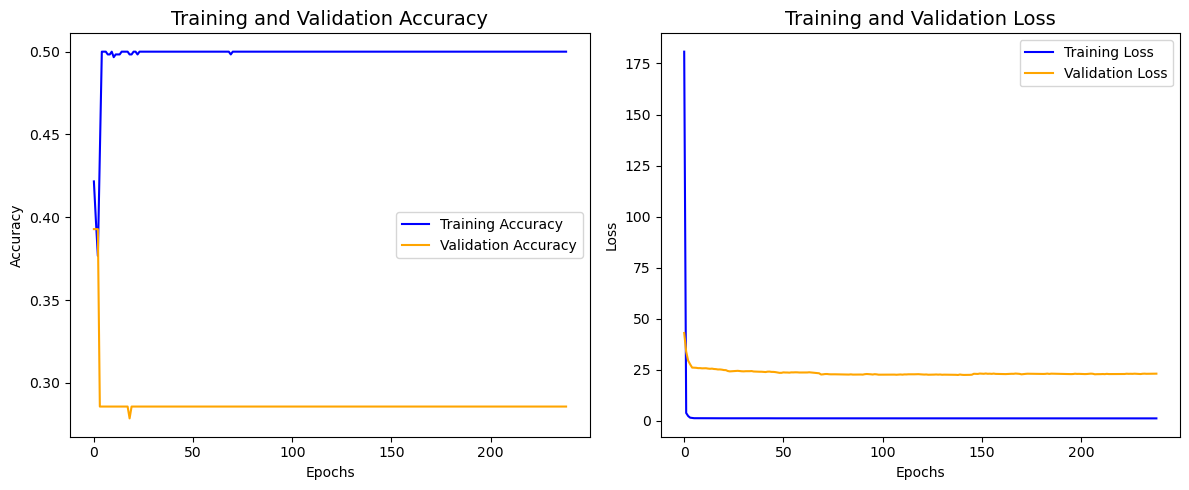

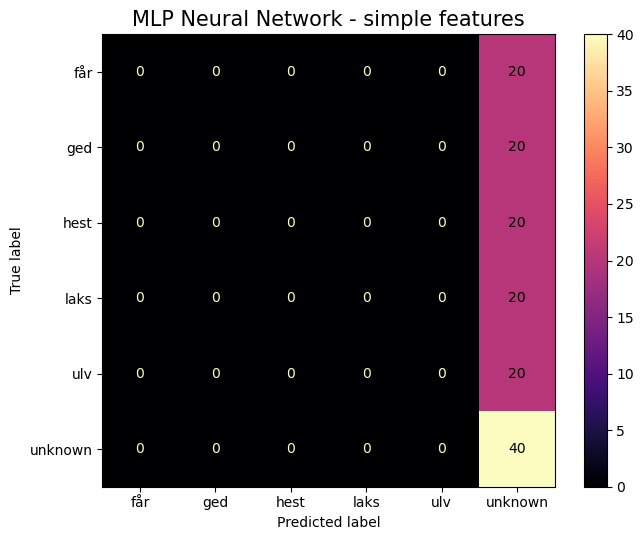

Accuracy: 0.286


In [6]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - simple features",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

ved at bruge de simple features, gav ikke nogen resultater og klassificerede en del forkerte og learning kurve viser at modellen hurtigt overfitter. Dette er features der ikke indeholder nok Nu forsøges der med MFCC

In [7]:
# =========================
# Choosing feature to train and test from
feat_name = "mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)


input_dim = X_train.shape[1]    # used for making the input dimension for the model
# =========================

model_mfcc = models.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),
    
    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mfcc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,798 (14.84 KB)

 Trainable params: 3,798 (14.84 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mfcc.compile(
    optimizer=tf.keras.optimizers.SGD(0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mfcc.fit(
    X_train_np, y_train_enc,
    validation_data=(X_test_np, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mfcc.predict(X_test_np)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2350 - loss: 5.7072 - val_accuracy: 0.2000 - val_loss: 2.7299
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4083 - loss: 1.8762 - val_accuracy: 0.2143 - val_loss: 2.2818
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4083 - loss: 1.7004 - val_accuracy: 0.2214 - val_loss: 2.1005
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4250 - loss: 1.6293 - val_accuracy: 0.2143 - val_loss: 1.9775
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4200 - loss: 1.5899 - val_accuracy: 0.2214 - val_loss: 1.9277
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4300 - loss: 1.5555 - val_accuracy: 0.2214 - val_loss: 1.8632
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4267 - loss: 1.5320 - val_accuracy: 0.2286 - val_loss: 1.8368
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4433 - loss: 1.5118 - val_accuracy: 0

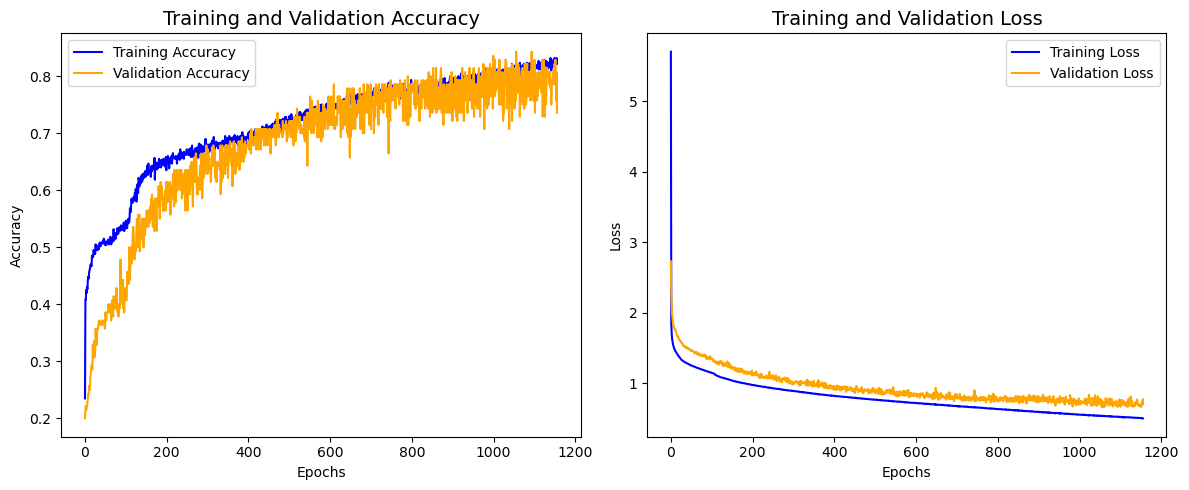

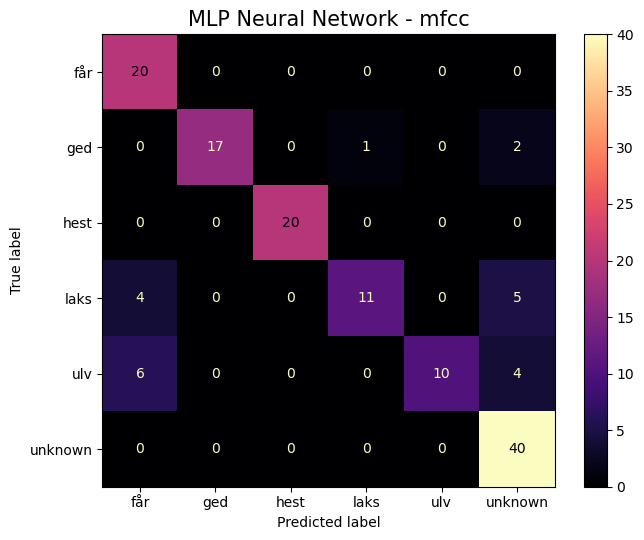

Accuracy: 0.843


In [9]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - mfcc",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Med MFCC fås et bedre accuracy, og viser samme tegn, som med simple features, og viser potentiale for at den finder mønster på MFCC resultatet. Vi forsøger nu med mel.

In [10]:
# =========================
# Choosing feature to train and test from
feat_name = "mel"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

 
 

input_dim = X_train.shape[1]    # used for making the input dimension for the model
# =========================

model_mel = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,798 (14.84 KB)

 Trainable params: 3,798 (14.84 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mel.compile(
    optimizer=tf.keras.optimizers.SGD(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mel.fit(
    X_train_np, y_train_enc,
    validation_data=(X_test_np, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mel.predict(X_test_np)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1150 - loss: 1.9259 - val_accuracy: 0.0500 - val_loss: 1.9729
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1617 - loss: 1.9213 - val_accuracy: 0.0000e+00 - val_loss: 1.9681
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1717 - loss: 1.9164 - val_accuracy: 0.0000e+00 - val_loss: 1.9637
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1883 - loss: 1.9120 - val_accuracy: 0.0000e+00 - val_loss: 1.9593
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2017 - loss: 1.9075 - val_accuracy: 0.0000e+00 - val_loss: 1.9549
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2150 - loss: 1.9032 - val_accuracy: 0.0000e+00 - val_loss: 1.9506
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2233 - loss: 1.8989 - val_accuracy: 0.0071 - val_loss: 1.9463
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2283 - loss: 1.89

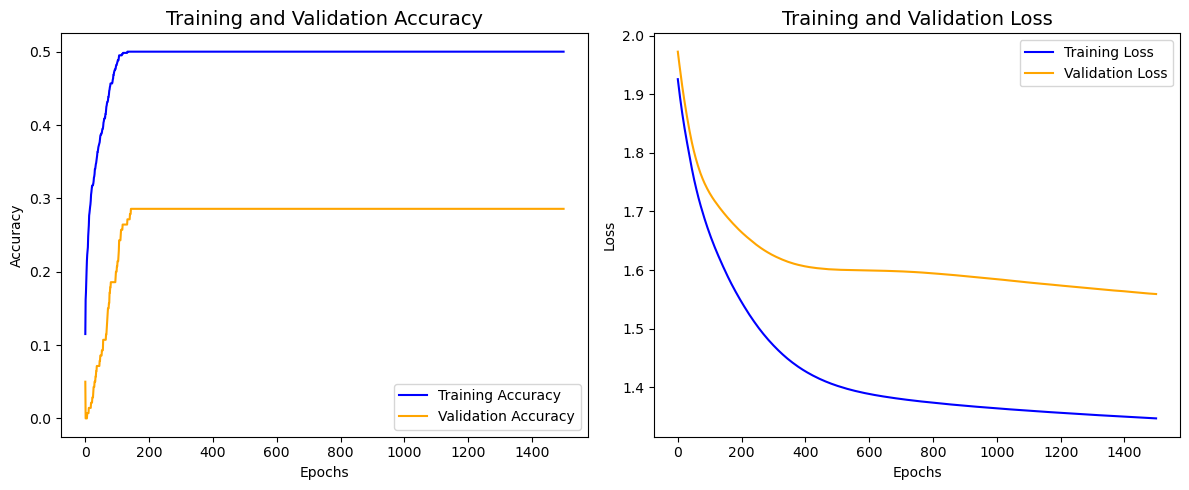

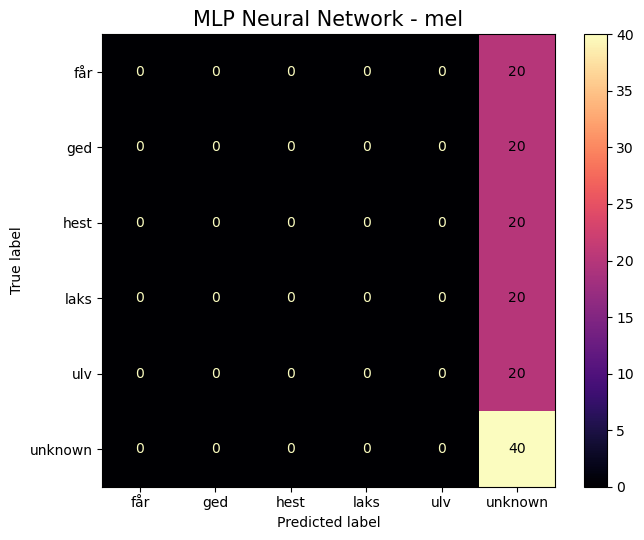

Accuracy: 0.286


In [12]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - mel",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Det ses at med MEL, klassificerer modellen alle inputs som "unknown" og fungerer på ingen måde som den bedste feature at bruge. Vi forsøger nu med at kombinerer simple features og MFCC features, og ser hvilken effekt det vil have for modellen, om den kan finde mønstrene fra begge features og blive bedre.

In [13]:
# =========================
# Choosing feature to train and test from
feat_name = "Simplefeat_mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

 
 

input_dim = X_train.shape[1]    # used for making the input dimension for the model
# =========================

model_mfcc_simplefeat = models.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_mfcc_simplefeat.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,374 (17.09 KB)

 Trainable params: 4,374 (17.09 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_mfcc_simplefeat.compile(
    optimizer=tf.keras.optimizers.SGD(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mfcc_simplefeat.fit(
    X_train_np, y_train_enc,
    validation_data=(X_test_np, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_mfcc_simplefeat.predict(X_test_np)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4150 - loss: 152.2566 - val_accuracy: 0.4143 - val_loss: 99.6408
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4000 - loss: 7.9110 - val_accuracy: 0.3714 - val_loss: 79.8071
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4117 - loss: 5.2417 - val_accuracy: 0.3929 - val_loss: 75.4480
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4083 - loss: 4.0307 - val_accuracy: 0.2857 - val_loss: 66.7848
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4967 - loss: 2.6840 - val_accuracy: 0.2857 - val_loss: 62.8010
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4967 - loss: 2.0558 - val_accuracy: 0.2786 - val_loss: 61.2569
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4983 - loss: 2.0580 - val_accuracy: 0.2786 - val_loss: 59.3581
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5033 - loss: 1.8872 - val_ac

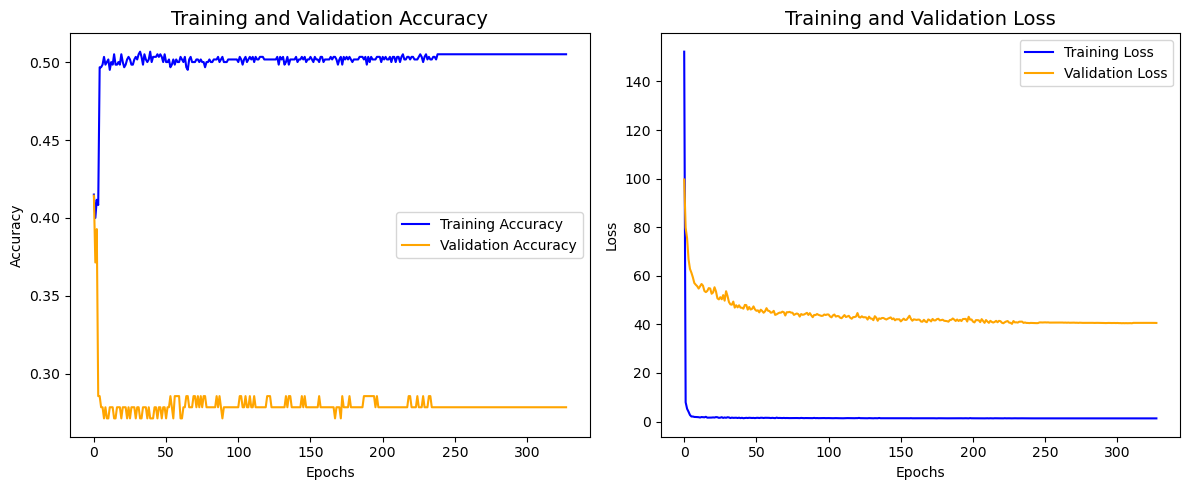

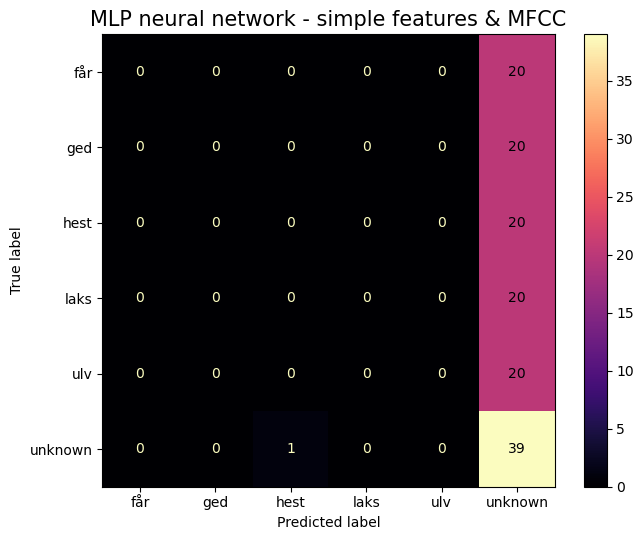

Accuracy: 0.279


In [15]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP neural network - simple features & MFCC",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Det ses det ikke gav et bedre resultat. Der testes nu med alle features kombineret og tjekker resultatet af confusion matricen.

In [16]:
# =========================
# Choosing feature to train and test from
feat_name = "combined"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

 
 

input_dim = X_train.shape[1]    # used for making the input dimension for the model
# =========================

model_allfeat = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(64),
    layers.ReLU(),

    layers.Dense(32),
    layers.ReLU(),

    layers.Dense(16),
    layers.ReLU(),

    layers.Dense(6, activation='softmax')
])

model_allfeat.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,398 (21.09 KB)

 Trainable params: 5,398 (21.09 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

model_allfeat.compile(
    optimizer=tf.keras.optimizers.SGD(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_allfeat.fit(
    X_train_np, y_train_enc,
    validation_data=(X_test_np, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

# =========================
# PREDICT
y_prob = model_allfeat.predict(X_test_np)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test.values
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred)
# =========================

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4167 - loss: 650.7150 - val_accuracy: 0.2643 - val_loss: 10.2370
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4767 - loss: 1.5095 - val_accuracy: 0.2857 - val_loss: 10.1140
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.3977 - val_accuracy: 0.2857 - val_loss: 10.3758
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.3917 - val_accuracy: 0.2857 - val_loss: 10.8742
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.3856 - val_accuracy: 0.2857 - val_loss: 11.2861
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.3768 - val_accuracy: 0.2857 - val_loss: 12.0755
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.5991 - val_accuracy: 0.2786 - val_loss: 1.5563
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4983 - loss: 1.4948 - val_acc

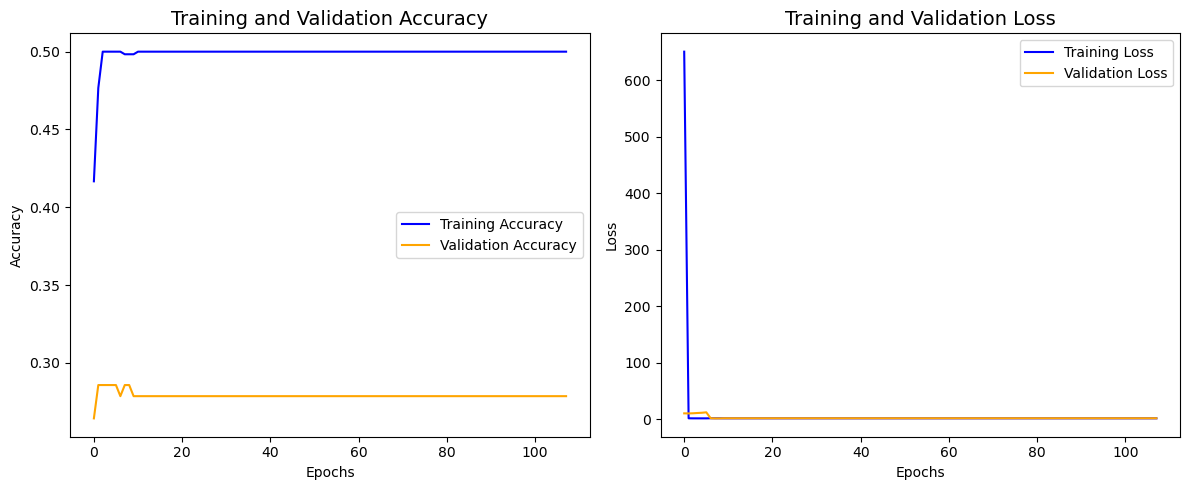

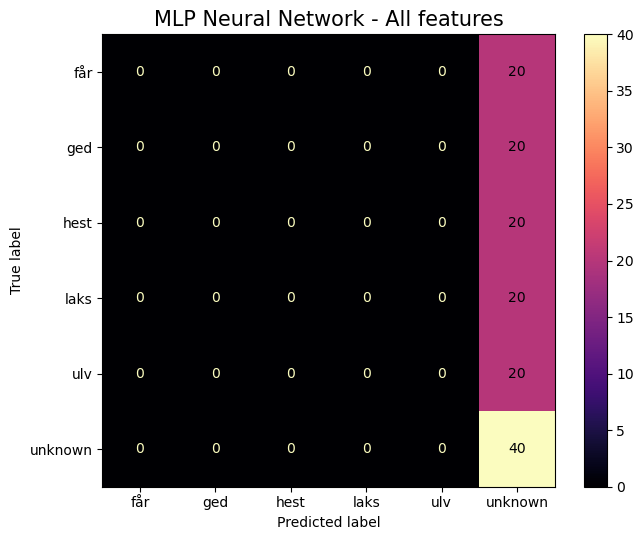

Accuracy: 0.286


In [18]:

import matplotlib.pyplot as plt

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=ALL_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_LABELS
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - All features",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

In [19]:
#model_mfcc.save('MFCC_KWS_MLP_Model.h5')
#model_mfcc.save('MFCC_KWS_MLP_Model.keras')

Det ses tydeligt at ved brug af MFCC feature alene, som input for modellen, giver den højeste accuracy og vælger at bruge den fremover. Der eksisterer andre modeller til keyword spotting der er bedre end MLP modellen, såsom convolution neural network.

## Convolutional Neural Network (CNN)
Efter at have undersøgt om keyword spotting, er det tænkt at implementere DS-CNN, da den er en mere effektiv alternativ til CNN (https://link.springer.com/article/10.1186/s13636-020-00176-2). Men da det er tænkt at bruge AIfES til at implementere modellen i C kode til mikrokontrolleren, er det ikke muligt at implementere den, da AIfES blandt andre funktioner ikke har "depthwiseConv2D" lag implementeret. Det vælges derfor at implementere en simpel CNN model.

For at kunne bruge MFCC til vores CNN skal vi udregne MFCC spectrogrammer og ikke bruge en tabular MFCC som vi har brugt tidligere:

In [20]:
# =========================
# MFCC SPECTROGRAM

FRAME_LENGTH = 400      # 25 ms at 16kHz
FRAME_STEP = 160        # 10 ms hop
N_MELS = 16
N_MFCC = 16

def frame_signal(x, frame_length=FRAME_LENGTH, frame_step=FRAME_STEP):
    frames = []

    for start in range(0, len(x) - frame_length + 1, frame_step):
        frame = x[start:start + frame_length]
        frames.append(frame)

    return np.array(frames, dtype=np.float32)


def mfcc_spectrogram(
    x,
    fs,
    frame_length=FRAME_LENGTH,
    frame_step=FRAME_STEP,
    n_mfcc=N_MFCC,
    n_mels=N_MELS,
    fft_n=512
):
    frames = frame_signal(
        x,
        frame_length=frame_length,
        frame_step=frame_step
    )

    spec = []

    for frame in frames:

        mfcc = mfcc_features_emlearn_style(
            frame,
            fs,
            n_mfcc=n_mfcc,
            n_mels=n_mels,
            fft_n=fft_n
        )

        spec.append(mfcc)

    spec = np.array(spec, dtype=np.float32)

    return spec

# =========================

Modellen vi bruger er:

```python

CNN_Model = models.Sequential([

    layers.Input(shape=(49, 16, 1)),

    layers.Conv2D(
        8,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D( 16, (3,3), activation='relu', padding='same' ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(32, activation='relu'),

    layers.Dense(len(ALL_LABELS), activation='softmax')
])
´´´

Vi træner og tester med samme eller lignende parametre, som brugt tidligere.

In [21]:
X_test = []
y_test = []
X_train = []
y_train = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        X_train.append(mfcc_spectrogram(x, SAMPLE_RATE))
        y_train.append(label)


for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    X_train.append(mfcc_spectrogram(x, SAMPLE_RATE))
    y_train.append("unknown")

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        X_test.append(mfcc_spectrogram(x, SAMPLE_RATE))
        y_test.append(label)


X_train = np.array(X_train, dtype=np.float32)
X_train = X_train[..., np.newaxis]

X_test = np.array(X_test, dtype=np.float32)
X_test = X_test[..., np.newaxis]

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

        

In [22]:
print(X_test.shape)

(140, 98, 16, 1)


In [23]:
CNN_Model = models.Sequential([
    layers.Input(shape=(98, 16, 1)),
    layers.Conv2D(filters=8, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(ALL_LABELS), activation='softmax')
])

CNN_Model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 16, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 8, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,662 (393.21 KB)

 Trainable params: 100,662 (393.21 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

CNN_Model.compile(
    optimizer=tf.keras.optimizers.SGD(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = CNN_Model.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)



Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3633 - loss: 5.5766 - val_accuracy: 0.1714 - val_loss: 3.7458
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5050 - loss: 1.9612 - val_accuracy: 0.5429 - val_loss: 1.4688
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5200 - loss: 1.5917 - val_accuracy: 0.4286 - val_loss: 1.9767
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6267 - loss: 1.1204 - val_accuracy: 0.5000 - val_loss: 1.4221
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6700 - loss: 0.9661 - val_accuracy: 0.6714 - val_loss: 1.0686
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6950 - loss: 0.9243 - val_accuracy: 0.7286 - val_loss: 0.9247
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7333 - loss: 0.8438 - val_accuracy: 0.6286 - val_loss: 1.0599
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7567 - loss: 0.7214 - val_accuracy: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


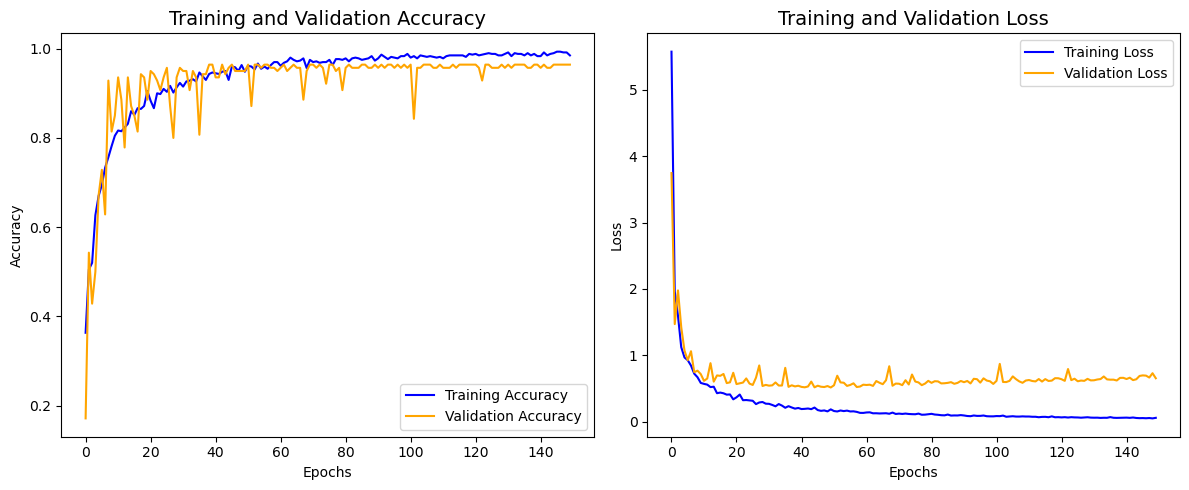

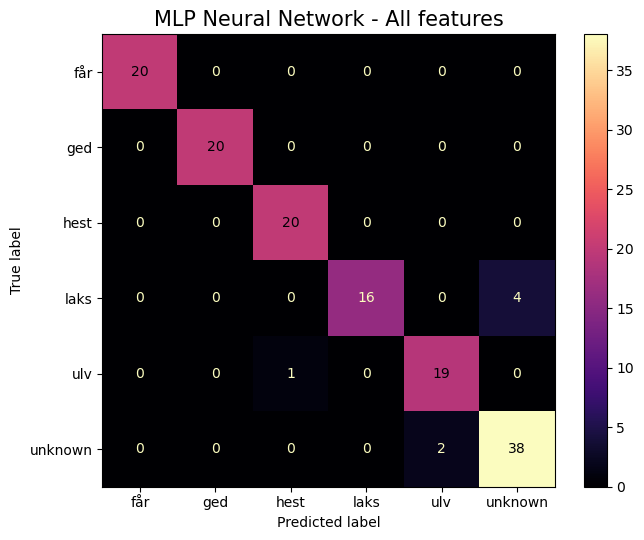

Accuracy: 0.950


In [ ]:

# =========================
# PREDICT
y_prob = CNN_Model.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test_enc
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred_idx)
# =========================

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX


cm = confusion_matrix(y_test_enc, y_pred_idx)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - MFCC spectrogram",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

Her observeres at modellen har en god accuracy, bedre end MLP-NN. vi vælger at bruge denne model til implementering på vores processor.

In [26]:
#CNN_Model.save('MFCC_KWS_CNN_Model.h5')
#CNN_Model.save('MFCC_KWS_CNN_Model.keras')

In [27]:
import tensorflow as tf
final_model = tf.keras.models.load_model('final models/MFCC_KWS_CNN_Model.keras')
final_model.summary()

for i, layer in enumerate(final_model.layers):
    try:
        w = layer.get_weights()
        print(i, layer.name, "WEIGHTS")
    except:
        print(i, layer.name, "NO WEIGHTS")

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 16, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 8, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 49, 8, 16)      │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 4, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │        49,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,262 (395.56 KB)

 Trainable params: 50,630 (197.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,632 (197.79 KB)

0 conv2d WEIGHTS
1 max_pooling2d WEIGHTS
2 conv2d_1 WEIGHTS
3 max_pooling2d_1 WEIGHTS
4 flatten WEIGHTS
5 dense_20 WEIGHTS
6 dense_21 WEIGHTS


før vi kan implementere modellen i AIfES skal vi bruge vægtene i lagene fra den trænet model.

In [28]:
for layer in final_model.layers:

    weights = layer.get_weights()

    if len(weights) == 0:
        continue

    print("\n====================")
    print("Layer:", layer.name)
    print("====================")

    for i, w in enumerate(weights):
        print(f"\nTensor {i}:")
        print(w)


Layer: conv2d

Tensor 0:
[[[[ 0.08811681 -0.0113709  -0.00988541 -0.2571507   0.09368221
    -0.10292629 -0.08328941  0.18747066]]

  [[-0.19684997  0.04844759 -0.19811347  0.19042595  0.15163542
     0.03820571  0.16977721 -0.07631238]]

  [[ 0.2581656   0.00781089 -0.2629936  -0.03673561  0.11758373
     0.0618127   0.154115    0.17461683]]]


 [[[ 0.15088856  0.25908744 -0.17730072 -0.19019811 -0.04016878
     0.21524467  0.0076945  -0.20997879]]

  [[-0.16141565  0.23312192  0.10508745  0.0656386   0.17405029
    -0.05377956  0.12758501  0.12038632]]

  [[ 0.20805387 -0.2737748  -0.24422798 -0.2505931  -0.00063633
     0.0387416  -0.21175066 -0.16675797]]]


 [[[-0.04971161 -0.12098378 -0.10823493 -0.20900154 -0.14841491
    -0.23162402 -0.12179782  0.19353344]]

  [[-0.08698877 -0.19580589 -0.05207712 -0.04717768  0.23729336
     0.29981273 -0.25653148  0.21133742]]

  [[ 0.20357782 -0.04874254 -0.15243499  0.03404927  0.10244459
     0.05946149  0.27599806 -0.1682781 ]]]]

Tenso

In [29]:

# =========================
# CONV LAYERS
# =========================

conv1_w, conv1_b = final_model.layers[0].get_weights()   # Conv2D (8 filters)
conv2_w, conv2_b = final_model.layers[2].get_weights()   # Conv2D (16 filters)

# =========================
# DENSE LAYERS
# =========================

dense1_w, dense1_b = final_model.layers[5].get_weights()  # Dense(32)
dense2_w, dense2_b = final_model.layers[6].get_weights()  # Output layer

# =========================
# FLATTEN FOR C EXPORT
# =========================

conv1_w_flat = conv1_w.flatten()
conv1_b_flat = conv1_b.flatten()

conv2_w_flat = conv2_w.flatten()
conv2_b_flat = conv2_b.flatten()

dense1_w_flat = dense1_w.flatten()
dense1_b_flat = dense1_b.flatten()

dense2_w_flat = dense2_w.flatten()
dense2_b_flat = dense2_b.flatten()



In [30]:
# print conv1
print("/* Conv1 Weights */")
print("float conv1_weights[] = {")
for v in conv1_w_flat:
    print(f"  {v:.6f},")
print("};")

print("float conv1_bias[] = {")
for v in conv1_b_flat:
    print(f"  {v:.6f},")
print("};")

/* Conv1 Weights */
float conv1_weights[] = {
  0.088117,
  -0.011371,
  -0.009885,
  -0.257151,
  0.093682,
  -0.102926,
  -0.083289,
  0.187471,
  -0.196850,
  0.048448,
  -0.198113,
  0.190426,
  0.151635,
  0.038206,
  0.169777,
  -0.076312,
  0.258166,
  0.007811,
  -0.262994,
  -0.036736,
  0.117584,
  0.061813,
  0.154115,
  0.174617,
  0.150889,
  0.259087,
  -0.177301,
  -0.190198,
  -0.040169,
  0.215245,
  0.007695,
  -0.209979,
  -0.161416,
  0.233122,
  0.105087,
  0.065639,
  0.174050,
  -0.053780,
  0.127585,
  0.120386,
  0.208054,
  -0.273775,
  -0.244228,
  -0.250593,
  -0.000636,
  0.038742,
  -0.211751,
  -0.166758,
  -0.049712,
  -0.120984,
  -0.108235,
  -0.209002,
  -0.148415,
  -0.231624,
  -0.121798,
  0.193533,
  -0.086989,
  -0.195806,
  -0.052077,
  -0.047178,
  0.237293,
  0.299813,
  -0.256531,
  0.211337,
  0.203578,
  -0.048743,
  -0.152435,
  0.034049,
  0.102445,
  0.059461,
  0.275998,
  -0.168278,
};
float conv1_bias[] = {
  0.000010,
  -0.000227,
  

In [31]:
print("/* Conv2 Weights */")
print("float conv2_weights[] = {")
for v in conv2_w_flat:
    print(f"  {v:.6f},")
print("};")

print("float conv2_bias[] = {")
for v in conv2_b_flat:
    print(f"  {v:.6f},")
print("};")

/* Conv2 Weights */
float conv2_weights[] = {
  -0.069689,
  0.075223,
  -0.002837,
  -0.088143,
  0.102513,
  0.102999,
  -0.079939,
  -0.028921,
  -0.116865,
  -0.033176,
  0.053674,
  -0.040274,
  0.023493,
  -0.098855,
  0.138718,
  0.012234,
  0.057485,
  -0.130710,
  -0.089227,
  0.044710,
  -0.045738,
  0.079788,
  0.021114,
  0.111049,
  0.100406,
  -0.079614,
  0.049342,
  0.077370,
  -0.010864,
  -0.089520,
  -0.025011,
  0.025238,
  0.082132,
  0.050378,
  0.117339,
  0.090766,
  -0.154298,
  -0.075381,
  -0.005301,
  -0.064396,
  0.069528,
  -0.017379,
  0.114659,
  -0.044616,
  -0.003088,
  0.113040,
  0.151978,
  -0.135821,
  0.070421,
  -0.014556,
  -0.127010,
  -0.156437,
  0.057558,
  0.121268,
  -0.006932,
  -0.067650,
  -0.160179,
  -0.032980,
  0.018786,
  0.085105,
  -0.100867,
  0.099666,
  0.029978,
  0.098182,
  0.079298,
  0.134949,
  0.092074,
  0.103823,
  0.170523,
  0.075796,
  0.019520,
  -0.137238,
  -0.055184,
  0.112323,
  -0.135654,
  0.037920,
  0.113

In [32]:
print("/* Dense1 Weights */")
print("float dense1_weights[] = {")
for v in dense1_w_flat:
    print(f"  {v:.6f},")
print("};")

print("float dense1_bias[] = {")
for v in dense1_b_flat:
    print(f"  {v:.6f},")
print("};")

/* Dense1 Weights */
float dense1_weights[] = {
  0.012012,
  -0.044173,
  -0.038403,
  -0.010036,
  -0.030097,
  0.005773,
  -0.049253,
  0.012618,
  0.023449,
  -0.004920,
  0.028293,
  -0.057262,
  0.043917,
  0.003402,
  -0.047177,
  0.009985,
  -0.059847,
  0.048844,
  -0.035777,
  -0.050618,
  -0.045010,
  0.014951,
  -0.045104,
  0.045887,
  -0.040030,
  0.056154,
  0.048827,
  0.007129,
  0.035186,
  0.012376,
  0.018991,
  0.060024,
  0.049662,
  0.039682,
  0.054469,
  -0.012004,
  -0.031088,
  0.004313,
  0.005120,
  -0.038575,
  0.045689,
  0.032768,
  0.002573,
  0.018303,
  0.013698,
  -0.030484,
  -0.009697,
  0.037864,
  0.037171,
  0.003819,
  -0.029625,
  0.054276,
  0.013398,
  -0.026895,
  0.019792,
  0.043699,
  -0.041613,
  -0.003164,
  -0.052311,
  0.053096,
  0.036028,
  0.010460,
  -0.018640,
  0.048971,
  0.037238,
  -0.042706,
  -0.062426,
  0.013688,
  0.057338,
  0.056514,
  -0.058737,
  -0.051876,
  0.009167,
  0.055683,
  0.050106,
  0.016111,
  -0.029880

In [33]:
print("/* Output Weights */")
print("float dense2_weights[] = {")
for v in dense2_w_flat:
    print(f"  {v:.6f},")
print("};")

print("float dense2_bias[] = {")
for v in dense2_b_flat:
    print(f"  {v:.6f},")
print("};")

/* Output Weights */
float dense2_weights[] = {
  0.254430,
  0.154338,
  0.241068,
  0.134010,
  0.331973,
  -0.180334,
  0.220101,
  0.352818,
  -0.395545,
  0.327961,
  -0.056459,
  -0.247503,
  0.127297,
  0.228889,
  -0.187682,
  -0.068004,
  0.152168,
  -0.070224,
  0.389769,
  0.076983,
  0.360115,
  -0.074022,
  -0.131867,
  0.240117,
  0.207102,
  -0.304598,
  0.324601,
  -0.089517,
  -0.260378,
  0.095614,
  -0.339103,
  -0.293377,
  -0.088598,
  -0.375452,
  -0.059003,
  0.253560,
  0.275165,
  0.160835,
  -0.091674,
  0.235477,
  -0.256775,
  0.044800,
  -0.004574,
  -0.190864,
  -0.114486,
  -0.138228,
  0.254158,
  -0.009697,
  0.331308,
  0.378164,
  -0.334060,
  0.220630,
  0.340997,
  0.032757,
  0.175992,
  -0.006839,
  -0.131880,
  -0.143612,
  0.044758,
  -0.245646,
  0.275199,
  -0.326596,
  0.160515,
  -0.322936,
  -0.088438,
  -0.130243,
  0.237209,
  0.207449,
  -0.255580,
  0.329984,
  0.167408,
  0.061982,
  0.115226,
  -0.300177,
  0.365086,
  -0.074334,
  -0

Vi har haft nogle problemer med at implementere CNN modellen, men har haft succes med MLP-NN modellen, på grund af compileringsfejl. Tradeoff er at MLP-NN har en accuracy på 0.85, mens CNN modellen har en på 0.95. Vi henter weights oh bias for MLP-modellen til implementeringen af modellen.

In [34]:
import tensorflow as tf
final_model = tf.keras.models.load_model('final models/MFCC_KWS_MLP_Model.keras')
final_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,598 (29.68 KB)

 Trainable params: 3,798 (14.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,800 (14.85 KB)

In [35]:
w1, b1 = final_model.layers[0].get_weights()  # first Dense layer
w2, b2 = final_model.layers[2].get_weights()  # second Dense layer
w3, b3 = final_model.layers[4].get_weights()  # third Dense layer
w4, b4 = final_model.layers[6].get_weights()  # fourth Dense layer

w1_flat = w1.flatten()
b1_flat = b1.flatten()

w2_flat = w2.flatten()
b2_flat = b2.flatten()

w3_flat = w3.flatten()
b3_flat = b3.flatten()

w4_flat = w4.flatten()
b4_flat = b4.flatten()


# 6) Print them as C arrays
print("/* Weights and biases for the first layer */")
print("float weights1[] = {")
for val in w1_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases1[] = {")
for val in b1_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the second layer */")
print("float weights2[] = {")
for val in w2_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases2[] = {")
for val in b2_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the third layer */")
print("float weights3[] = {")
for val in w3_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases3[] = {")
for val in b3_flat:
    print(f"  {val:.6f}f,")
print("};")

print("\n/* Weights and biases for the fourth layer */")
print("float weights4[] = {")
for val in w4_flat:
    print(f"  {val:.6f}f,")
print("};")
print("float biases4[] = {")
for val in b4_flat:
    print(f"  {val:.6f}f,")
print("};")



/* Weights and biases for the first layer */
float weights1[] = {
  0.104954f,
  0.246319f,
  -0.260782f,
  -0.082965f,
  -0.120466f,
  0.107030f,
  -0.183328f,
  0.263895f,
  -0.252350f,
  0.092339f,
  -0.148123f,
  0.039312f,
  0.166535f,
  -0.227095f,
  0.177709f,
  -0.066650f,
  -0.153181f,
  -0.075491f,
  0.026840f,
  -0.263623f,
  -0.187690f,
  0.268159f,
  -0.054077f,
  0.202740f,
  -0.188527f,
  -0.175056f,
  -0.258592f,
  0.258930f,
  -0.087834f,
  0.197748f,
  0.053050f,
  0.234695f,
  -0.063815f,
  0.151482f,
  -0.186655f,
  0.221368f,
  0.055139f,
  -0.025819f,
  0.219898f,
  -0.265097f,
  -0.144509f,
  0.182421f,
  0.168932f,
  -0.253211f,
  0.206854f,
  0.216010f,
  -0.070481f,
  0.063935f,
  -0.131603f,
  -0.107477f,
  -0.163230f,
  0.132377f,
  0.197137f,
  0.262656f,
  -0.256178f,
  -0.222576f,
  -0.021311f,
  -0.200011f,
  0.204744f,
  -0.010809f,
  0.151700f,
  0.039000f,
  0.120796f,
  -0.130714f,
  -0.253289f,
  -0.000046f,
  -0.297317f,
  -0.103890f,
  0.085280f,


In [57]:
# =========================
# Choosing feature to train and test from
feat_name = "mfcc"
feat_cols = feature_sets[feat_name]

X_train = train_df[feat_cols]
y_train = train_df["activity"]

X_test = test_df[feat_cols]
y_test = test_df["activity"]

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)


input_dim = X_train.shape[1]    # used for making the input dimension for the model
print(input_dim)
print(len(X_train))
# =========================

16
600


In [ ]:

CNN_model = models.Sequential([
    layers.Conv1D(filters=8, input_shape=(16, 1), kernel_size=3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(ALL_LABELS), activation='softmax')
])

CNN_model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 14, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,054 (8.02 KB)

 Trainable params: 2,054 (8.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=MODEL_PATIENCE,
    restore_best_weights=True
)

CNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = CNN_model.fit(
    X_train, y_train_enc,
    validation_data=(X_test, y_test_enc),
    epochs=MODEL_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2300 - loss: 3.2540 - val_accuracy: 0.2071 - val_loss: 1.9281
Epoch 2/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5433 - loss: 1.2275 - val_accuracy: 0.4500 - val_loss: 1.2760
Epoch 3/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6117 - loss: 0.9919 - val_accuracy: 0.6500 - val_loss: 0.9567
Epoch 4/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6617 - loss: 0.8755 - val_accuracy: 0.6929 - val_loss: 0.8576
Epoch 5/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7017 - loss: 0.7877 - val_accuracy: 0.7786 - val_loss: 0.7746
Epoch 6/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.7036 - val_accuracy: 0.8000 - val_loss: 0.6859
Epoch 7/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7817 - loss: 0.6345 - val_accuracy: 0.8429 - val_loss: 0.6353
Epoch 8/1500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7900 - loss: 0.5972 - val_accuracy: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


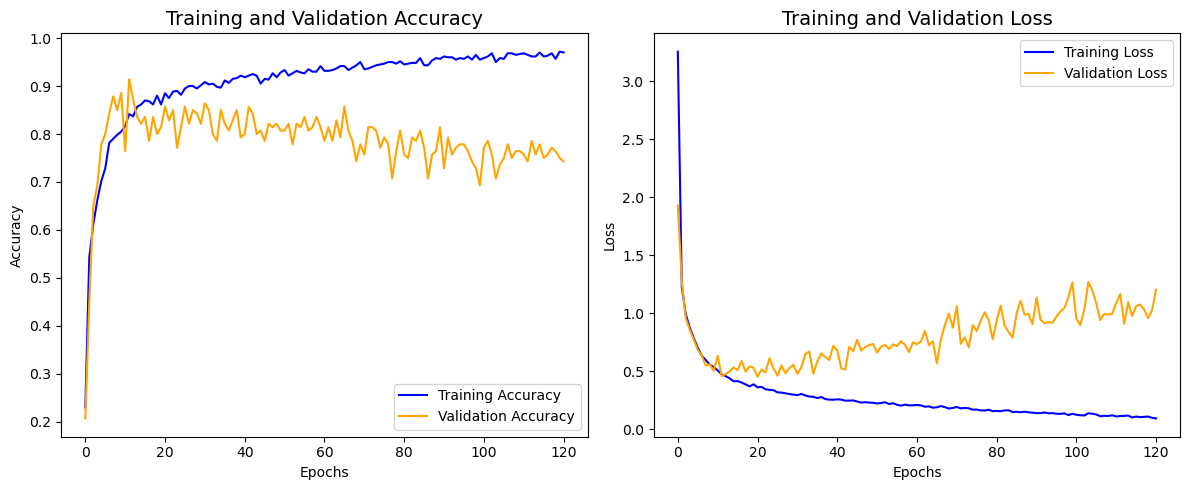

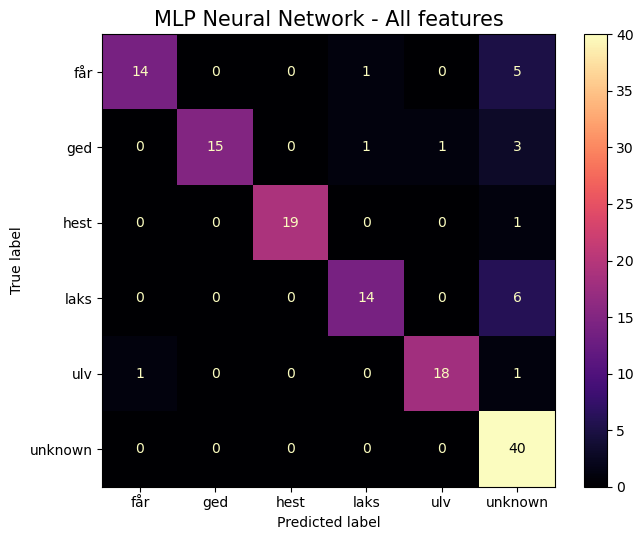

Accuracy: 0.857


In [61]:
# =========================
# PREDICT
y_prob = DSCNN_model.predict(X_test)

# probabilities -> indices
y_pred_idx = np.argmax(y_prob, axis=1)

# indices -> labels
y_pred = le.inverse_transform(y_pred_idx)

# true labels
y_true = y_test_enc
# =========================


# =========================
# ACCURACY
acc = accuracy_score(y_true, y_pred_idx)
# =========================

# =========================
# Learning curve
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy', color='blue')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy', color='orange')

plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
         label='Training Loss', color='blue')

plt.plot(history.history['val_loss'],
         label='Validation Loss', color='orange')

plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5.5))
# =========================

# =========================
# CONFUSION MATRIX


cm = confusion_matrix(y_test_enc, y_pred_idx)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="magma",
    values_format="d",
    colorbar=True
)

ax.set_title(
    f"MLP Neural Network - All features",
    fontsize=15
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.3f}")

referencer

1. https://ieeexplore.ieee.org/abstract/document/10050122
2. https://ieeexplore.ieee.org/document/10136648

3. https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/

4. https://backend.orbit.dtu.dk/ws/portalfiles/portal/216372364/S_rensen_et_al_2020_EURASIP_Journal_on_Audio_Speech_and_Music_Processing.pdf

5. https://www.mdpi.com/2079-9292/12/18/3964 